<a href="https://colab.research.google.com/github/WVF-1/Bike-Lane-Analysis/blob/main/Pittsburgh%20bike%20visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Bikes & Bike Lanes — Five Key Visuals

**Newsletter series: Geospatial Data & Public Transportation — Week 1, Notebook 3 (Standout Recap)**

Notebooks 1 and 2 did the work: pulling the street network, tagging bike infrastructure, joining Census bike-commute data by tract. This notebook is the payoff — five polished, publication-ready visuals built from the combined dataset, meant to stand on their own in the newsletter.

**Input:** just one file — `pittsburgh_bike_infrastructure_vs_commuting.csv`, the tract-level export from Notebook 2. We'll re-pull Census tract *geometries* (not data — just the shapes) via `pygris` so we can map it, since geometry doesn't travel in a CSV.

**The five visuals:**
1. Choropleth — where Pittsburghers actually bike to work
2. Choropleth — where bike infrastructure actually exists
3. Infrastructure vs. ridership scatter, with trend line
4. The "mismatch" chart — tracts where riders show up despite no lanes, and tracts with lanes nobody's using
5. Top-15 ranked bar chart — the borough's leading bike-commute tracts

## Setup

In [1]:
!pip install geopandas pygris -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 1.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pd.set_option("display.max_columns", 50)

# --- Pittsburgh-themed palette, used consistently across all five charts ---
PGH_GOLD   = "#FFB81C"
PGH_BLACK  = "#1a1a1a"
PGH_GREEN  = "#1f8f5f"   # bike-infra accent, carried over from Notebooks 1-2
PGH_STEEL  = "#4a6b8a"
PGH_GRAY   = "#d9d9d9"
CMAP_GREEN = "YlGn"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#444444",
    "axes.titleweight": "bold",
})


## Upload your Notebook 2 export

Just the one file this time: `pittsburgh_bike_infrastructure_vs_commuting.csv`.

In [3]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving pittsburgh_bike_infrastructure_vs_commuting.csv to pittsburgh_bike_infrastructure_vs_commuting.csv
Uploaded: ['pittsburgh_bike_infrastructure_vs_commuting.csv']


In [4]:
df = pd.read_csv("pittsburgh_bike_infrastructure_vs_commuting.csv", dtype={"GEOID": str})

# A handful of tracts had no OSM edges join in Notebook 2 (sparse/edge-of-boundary
# tracts) -- treat those as 0% infrastructure rather than dropping them, since a
# missing join here genuinely means "no matched bike infrastructure," not unknown data.
df["bike_infra_pct"] = df["bike_infra_pct"].fillna(0)
df["bike_commute_pct"] = df["bike_commute_pct"].fillna(0)

print(f"Tracts: {len(df)}")
df.head()


Tracts: 165


,GEOID,NAME,bike_commute_pct,bike_infra_pct,total_length_m,bike_infra_length_m
0,42003560500,5605.0,1.299505,0.000000,NaN,NaN
1,42003170200,1702.0,0.000000,9.512341,55568.698235,5285.884273
2,42003151600,1516.0,1.419558,3.120926,30977.199496,966.775558
3,42003100500,1005.0,2.762431,0.000000,19982.383018,0.000000
4,42003140400,1404.0,3.142184,0.000000,27143.943120,0.000000


## Re-attaching geometry

The CSV is tabular by design — geometry doesn't survive a CSV round-trip. We pull the *same* Census tract boundaries from Notebook 2 again (a shape lookup, not new data) and join on `GEOID`.

In [5]:
from pygris import tracts

pa_tracts = tracts(state="PA", county="Allegheny", cb=True, year=2022)
pa_tracts = pa_tracts.to_crs("EPSG:4326")[["GEOID", "geometry"]]

gdf = pa_tracts.merge(df, on="GEOID", how="inner")
print(f"Tracts with geometry + data: {len(gdf)}")


Using FIPS code '42' for input 'PA'
Using FIPS code '003' for input 'Allegheny'
Tracts with geometry + data: 165


---
## Visual 1: Where Pittsburghers Bike to Work

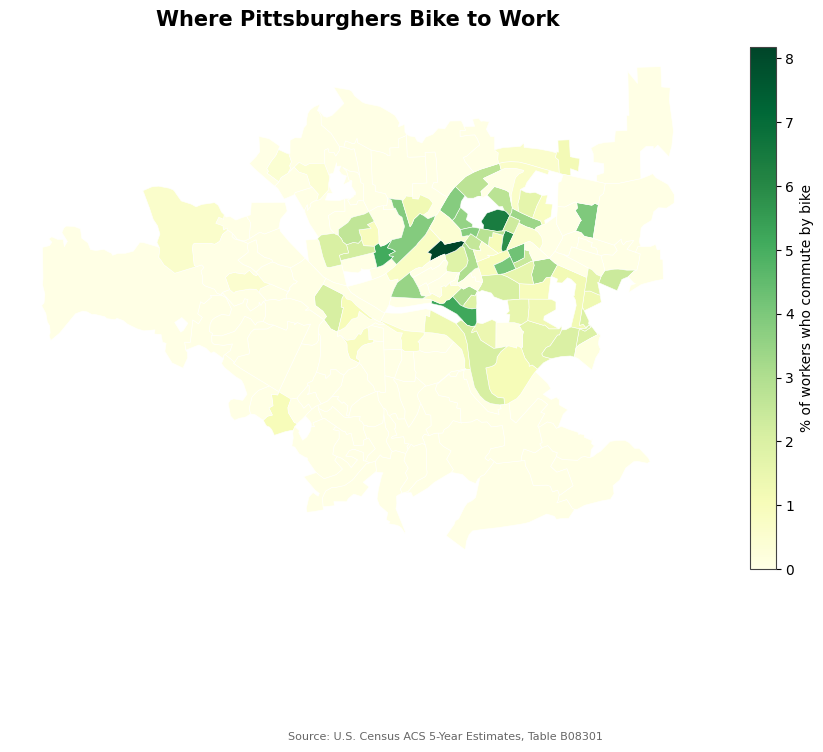

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))

gdf.plot(column="bike_commute_pct", cmap=CMAP_GREEN, edgecolor="white", linewidth=0.4,
          legend=True, ax=ax,
          legend_kwds={"label": "% of workers who commute by bike", "shrink": 0.6})

ax.set_title("Where Pittsburghers Bike to Work", fontsize=15, pad=12)
ax.set_axis_off()
fig.text(0.5, 0.02, "Source: U.S. Census ACS 5-Year Estimates, Table B08301", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("viz1_bike_commute_choropleth.png", dpi=200, bbox_inches="tight")
plt.show()


---
## Visual 2: Where the Bike Infrastructure Actually Is

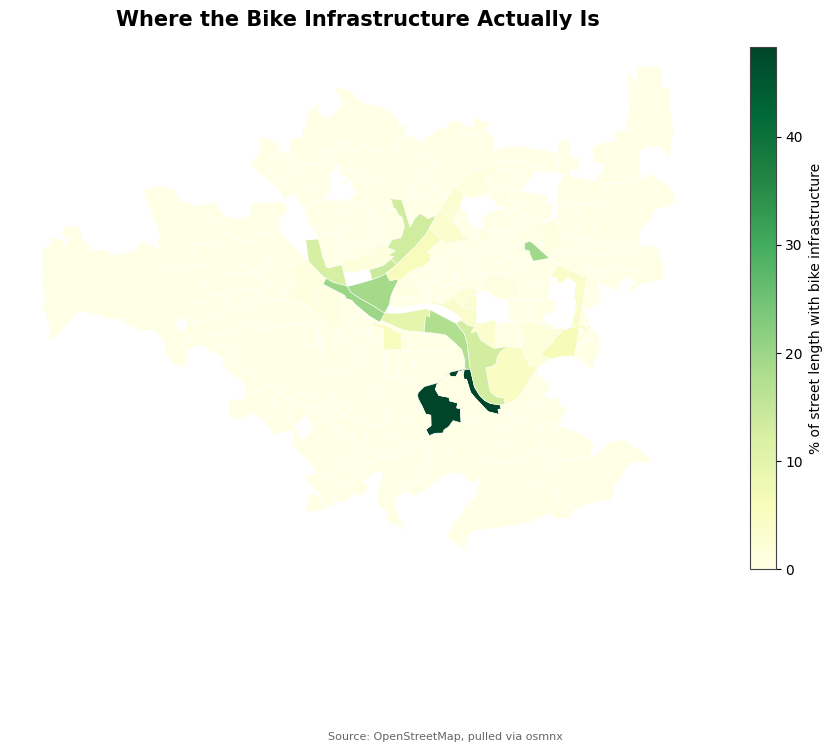

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))

gdf.plot(column="bike_infra_pct", cmap=CMAP_GREEN, edgecolor="white", linewidth=0.4,
          legend=True, ax=ax,
          legend_kwds={"label": "% of street length with bike infrastructure", "shrink": 0.6})

ax.set_title("Where the Bike Infrastructure Actually Is", fontsize=15, pad=12)
ax.set_axis_off()
fig.text(0.5, 0.02, "Source: OpenStreetMap, pulled via osmnx", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("viz2_bike_infra_choropleth.png", dpi=200, bbox_inches="tight")
plt.show()


---
## Visual 3: Infrastructure vs. Ridership

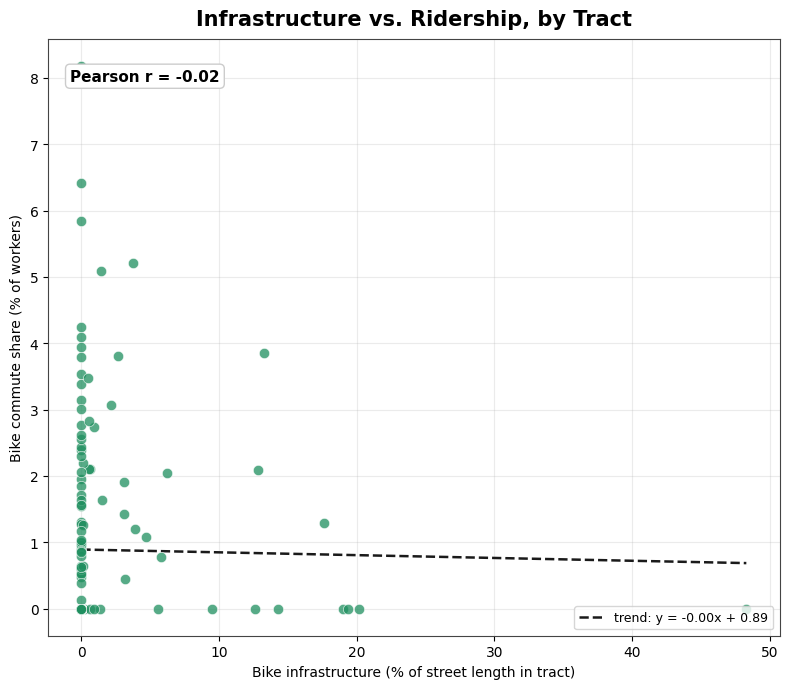

Note: correlation, not causation -- topography, density, and income all plausibly confound this relationship.


In [8]:
fig, ax = plt.subplots(figsize=(8, 7))

x = gdf["bike_infra_pct"].values
y = gdf["bike_commute_pct"].values

ax.scatter(x, y, s=55, alpha=0.75, color=PGH_GREEN, edgecolor="white", linewidth=0.5, zorder=3)

# Simple linear trend line
mask = np.isfinite(x) & np.isfinite(y)
if mask.sum() > 1:
    coeffs = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xs, np.polyval(coeffs, xs), color=PGH_BLACK, linewidth=1.8, linestyle="--", zorder=2,
            label=f"trend: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}")

r = np.corrcoef(x[mask], y[mask])[0, 1]
ax.text(0.03, 0.95, f"Pearson r = {r:.2f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#ccc"))

ax.set_xlabel("Bike infrastructure (% of street length in tract)")
ax.set_ylabel("Bike commute share (% of workers)")
ax.set_title("Infrastructure vs. Ridership, by Tract", fontsize=15, pad=10)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("viz3_infra_vs_ridership_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

print("Note: correlation, not causation -- topography, density, and income all plausibly confound this relationship.")


---
## Visual 4: The Infrastructure-Ridership "Mismatch"

Two interesting kinds of tract:
- **Riders without lanes** — high bike-commute share, little to no infrastructure. Grassroots ridership on unprotected streets.
- **Lanes without riders** — solid infrastructure, low bike-commute share. Underused investment, or a tract that's not primarily residential (offices, hospitals, etc.).

We rank tracts by the *gap* between a standardized ridership score and a standardized infrastructure score.

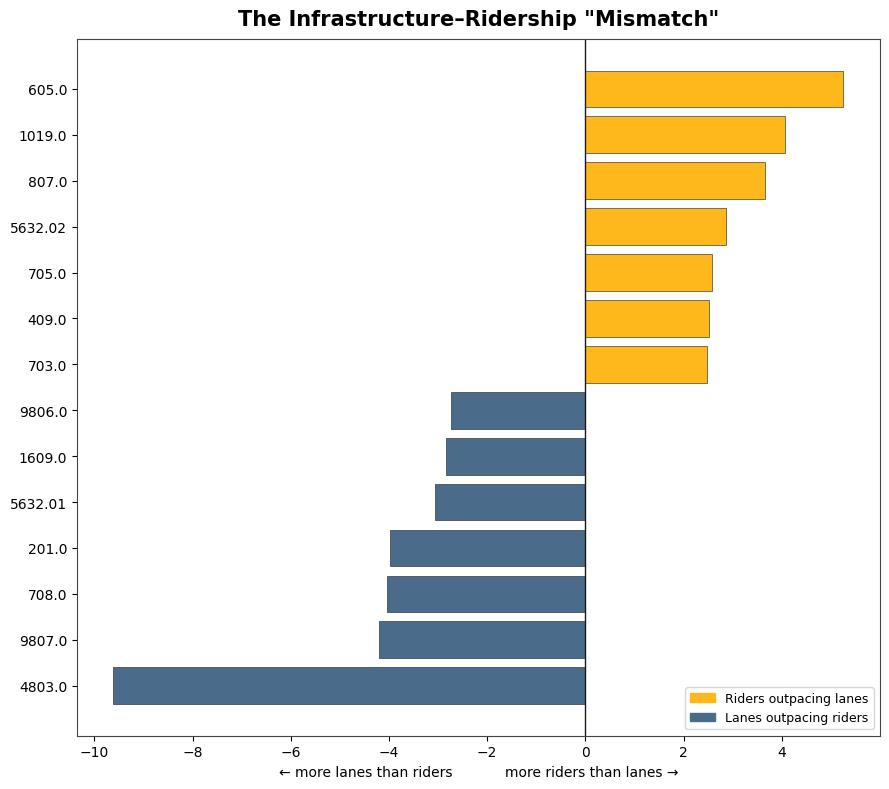

In [9]:
z = gdf.copy()
z["commute_z"] = (z["bike_commute_pct"] - z["bike_commute_pct"].mean()) / z["bike_commute_pct"].std()
z["infra_z"] = (z["bike_infra_pct"] - z["bike_infra_pct"].mean()) / z["bike_infra_pct"].std()
z["mismatch"] = z["commute_z"] - z["infra_z"]   # positive = riders outpacing lanes

top_riders_no_lanes = z.nlargest(7, "mismatch")[["NAME", "bike_commute_pct", "bike_infra_pct", "mismatch"]]
top_lanes_no_riders = z.nsmallest(7, "mismatch")[["NAME", "bike_commute_pct", "bike_infra_pct", "mismatch"]]

chart_df = pd.concat([
    top_riders_no_lanes.assign(group="Riders, few lanes"),
    top_lanes_no_riders.assign(group="Lanes, few riders"),
]).sort_values("mismatch")

fig, ax = plt.subplots(figsize=(9, 8))
colors = chart_df["group"].map({"Riders, few lanes": PGH_GOLD, "Lanes, few riders": PGH_STEEL})
ax.barh(chart_df["NAME"].astype(str), chart_df["mismatch"], color=colors, edgecolor=PGH_BLACK, linewidth=0.4)

ax.axvline(0, color=PGH_BLACK, linewidth=1)
ax.set_xlabel("← more lanes than riders            more riders than lanes →")
ax.set_title('The Infrastructure–Ridership "Mismatch"', fontsize=15, pad=10)

handles = [plt.Rectangle((0,0),1,1, color=PGH_GOLD), plt.Rectangle((0,0),1,1, color=PGH_STEEL)]
ax.legend(handles, ["Riders outpacing lanes", "Lanes outpacing riders"], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("viz4_infra_ridership_mismatch.png", dpi=200, bbox_inches="tight")
plt.show()


---
## Visual 5: Top 15 Tracts by Bike Commute Share

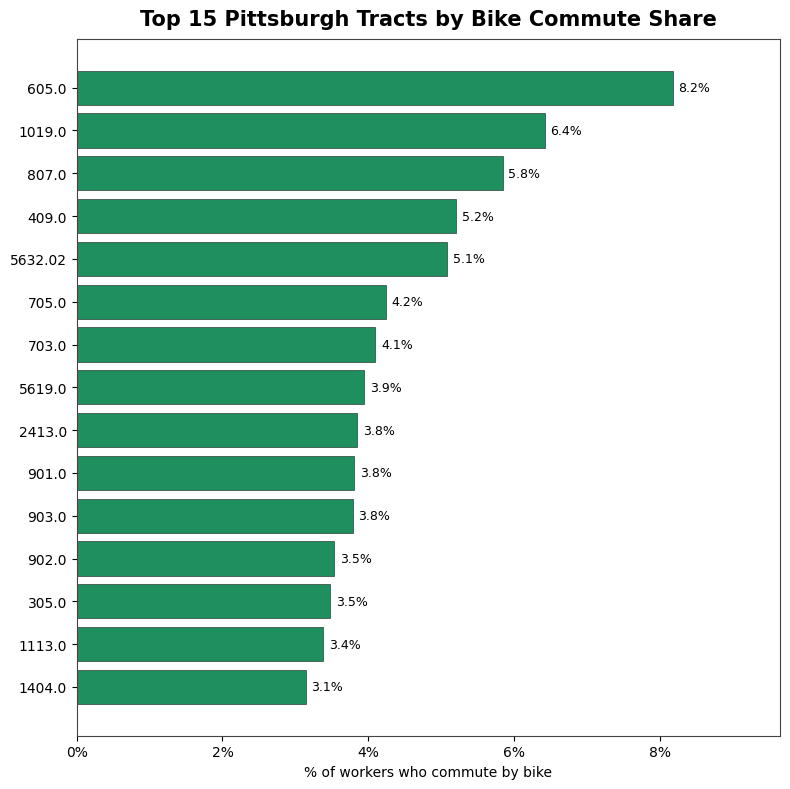

In [10]:
top15 = gdf.nlargest(15, "bike_commute_pct").sort_values("bike_commute_pct")

fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(top15["NAME"].astype(str), top15["bike_commute_pct"], color=PGH_GREEN, edgecolor=PGH_BLACK, linewidth=0.4)

for bar, val in zip(bars, top15["bike_commute_pct"]):
    ax.text(val + 0.08, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlabel("% of workers who commute by bike")
ax.set_title("Top 15 Pittsburgh Tracts by Bike Commute Share", fontsize=15, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xlim(0, top15["bike_commute_pct"].max() * 1.18)

plt.tight_layout()
plt.savefig("viz5_top15_bike_commute_tracts.png", dpi=200, bbox_inches="tight")
plt.show()


## Wrap-up

Five visuals, one dataset, zero manual downloads or license agreements along the way. That's the whole point of week 1's "Geospatial 101": geospatial data isn't exotic — it's regular data with one extra idea (location) layered on, and the tooling to work with it is a `pip install` away.

**All five PNGs are saved at 200 DPI**, ready to drop straight into the newsletter:
- `viz1_bike_commute_choropleth.png`
- `viz2_bike_infra_choropleth.png`
- `viz3_infra_vs_ridership_scatter.png`
- `viz4_infra_ridership_mismatch.png`
- `viz5_top15_bike_commute_tracts.png`

Next up: Week 3 picks the node/edge graph structure from Notebook 1 back up and turns it into a live traffic + streetlight simulation.

In [11]:
from google.colab import files

for fname in [
    "viz1_bike_commute_choropleth.png",
    "viz2_bike_infra_choropleth.png",
    "viz3_infra_vs_ridership_scatter.png",
    "viz4_infra_ridership_mismatch.png",
    "viz5_top15_bike_commute_tracts.png",
]:
    files.download(fname)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>